# Taller 4: Detección de contornos

## Cargue la imagen objects.png y visualícela.  Transforme la imagen a Int32 conservando los mismos niveles de gris originales (0 y 255).

In [1]:
PATH = "./imagenes/"

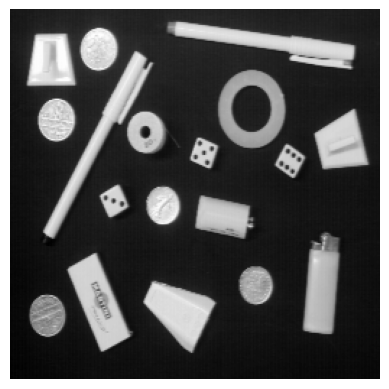

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


imagen = cv2.imread(PATH + "OBJECTS.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(imagen, cmap="gray")
plt.axis("off")
plt.show()

int32
7 188


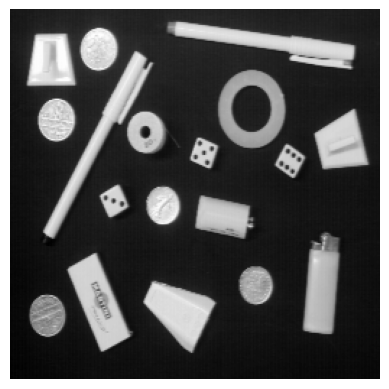

In [3]:
imagen_int32 = imagen.astype(np.int32)
print(imagen_int32.dtype)
print(imagen_int32.min(), imagen_int32.max())
plt.imshow(imagen_int32, cmap="gray")
plt.axis("off")
plt.show()

## Aplique un filtro de Sobel horizontal sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.

In [4]:

from skimage.filters import sobel_h, sobel_v, sobel

img_sh = sobel_h(imagen_int32)

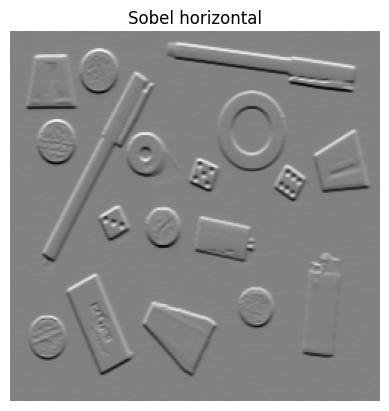

In [5]:
plt.imshow(img_sh, cmap="gray")
plt.title("Sobel horizontal")
plt.axis("off")
plt.show()

## Aplique un filtro de Sobel vertical sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.

In [6]:
#Aplica el filtro Sobel vertical
img_sv = sobel_v(imagen_int32)

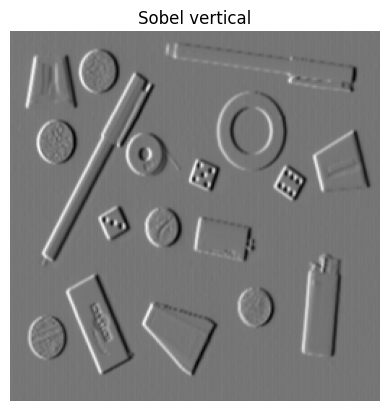

In [7]:
plt.imshow(img_sv, cmap="gray")
plt.title("Sobel vertical")
plt.axis("off")
plt.show()

Notamos que se resaltan bordes distintos al caso del filtro Sobel horizontal. Un ejemplo claro es el encedendor, donde podemos ver en blanco uno de los bordes verticales, el cual no se podía ver con el Sobel horizontal.

## Calcule la norma (magnitud) del gradiente de acuerdo con la definición a partir de las dos imágenes resultantes anteriores. Visualice los resultados.

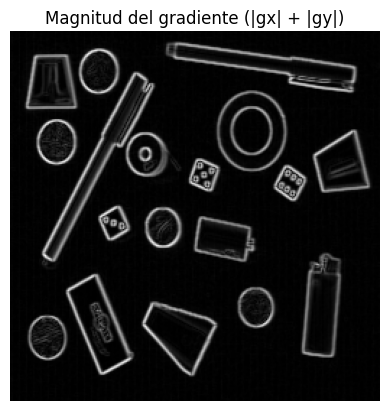

In [8]:
magnitud = np.abs(img_sh) + np.abs(img_sv)

plt.imshow(magnitud, cmap="gray")
plt.title("Magnitud del gradiente (|gx| + |gy|)")
plt.axis("off")
plt.show()

## Describa cualitativamente cada una de estas tres imágenes: imagen del gradiente en X, imagen del gradiente en Y e imagen de la norma del gradiente.

########### PENDIENTE

## Aplique un filtro de Sobel sobre la imagen y visualice los resultados. Compare la imagen con la obtenido en el punto anterior.

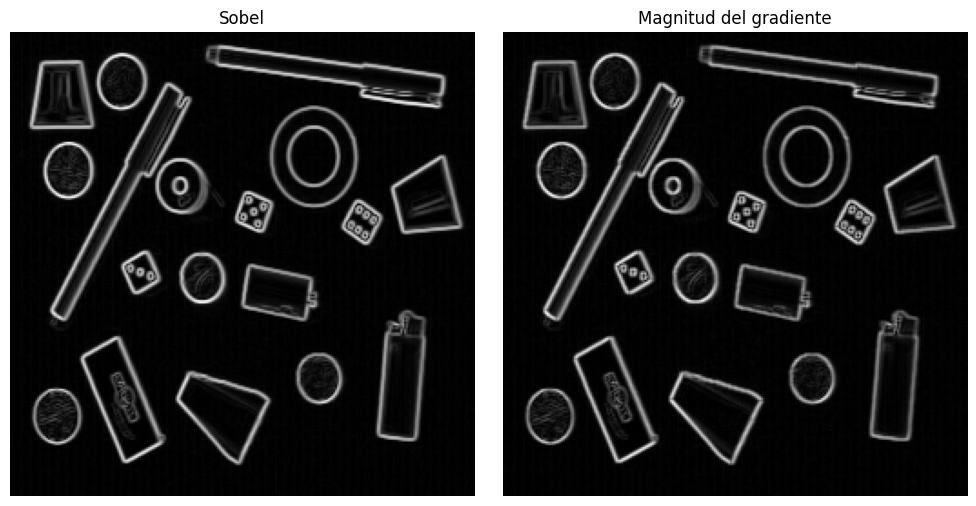

In [9]:
img_s = sobel(imagen_int32)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_s, cmap='gray')
axs[0].set_title('Sobel')
axs[0].axis('off')
axs[1].imshow(magnitud, cmap='gray')
axs[1].set_title('Magnitud del gradiente')
axs[1].axis('off')
plt.tight_layout()
plt.show()

In [10]:
# Calculamos el coeficiente Dice
A = magnitud.astype(bool)
B = img_s.astype(bool)

# Intersección
interseccion = np.logical_and(A, B).sum()

# Tamaños
size_A = A.sum()
size_B = B.sum()

# Dice
dice = (2 * interseccion) / (size_A + size_B)

print("Coeficiente Dice:", dice)

Coeficiente Dice: 1.0


LLegamos a la conclusión de que ambas imágenes son la misma.

## Aplique un filtro de Prewitt horizontal sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.

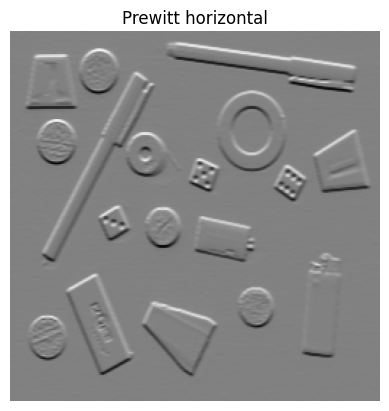

In [18]:
from skimage.filters import prewitt_h, prewitt_v, prewitt

#Aplica el filtro prewitt horizontal
img_ph = prewitt_h(imagen_int32)
plt.imshow(img_ph, cmap="gray")
plt.title("Prewitt horizontal")
plt.axis("off")
plt.show()


## Aplique un filtro de Prewitt vertical sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.

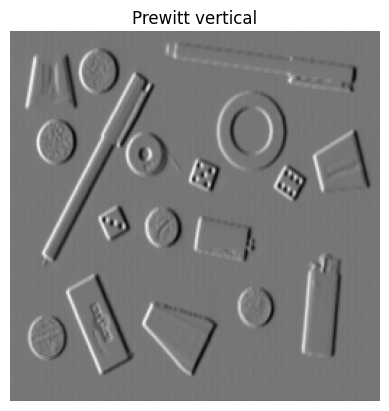

In [19]:
#Aplica el filtro prewitt vertical
img_pv = prewitt_v(imagen_int32)
plt.imshow(img_pv, cmap='grey')
plt.title("Prewitt vertical")
plt.axis("off")
plt.show()

## Calcule la norma (magnitud) del gradiente de acuerdo con la definición a partir de las dos imágenes resultantes anteriores. Visualice los resultados.

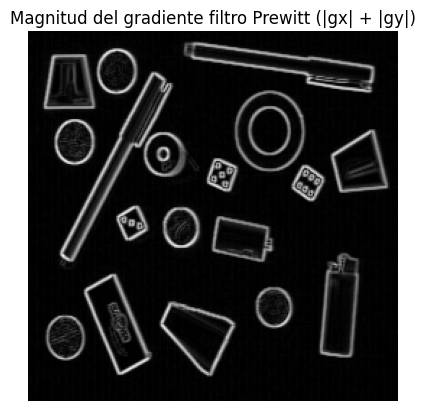

In [20]:
magnitud_prewitt = np.abs(img_ph) + np.abs(img_pv)

plt.imshow(magnitud_prewitt, cmap="gray")
plt.title("Magnitud del gradiente filtro Prewitt (|gx| + |gy|)")
plt.axis("off")
plt.show()

## Describa cualitativamente cada una de estas tres imágenes: imagen del gradiente en X, imagen del gradiente en Y e imagen de la norma del gradiente.

############## PENDIENTEE

## Aplique un filtro de Prewitt sobre la imagen y visualice los resultados. Compare la imagen con la obtenido en el punto anterior.

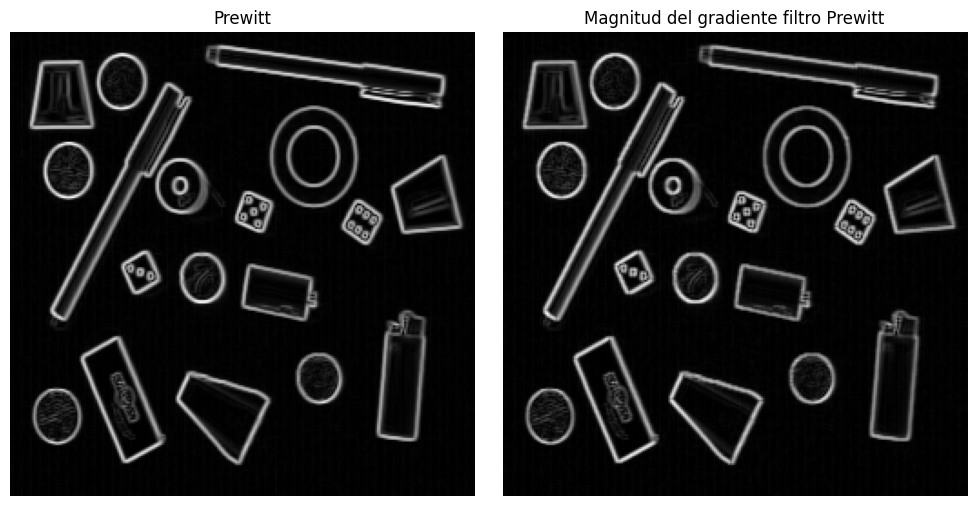

In [21]:
#Calcula bordes usando el filtro de prewitt
img_p = prewitt(imagen_int32)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img_p, cmap='gray')
axs[0].set_title('Prewitt')
axs[0].axis('off')
axs[1].imshow(magnitud_prewitt, cmap='gray')
axs[1].set_title('Magnitud del gradiente filtro Prewitt')
axs[1].axis('off')
plt.tight_layout()
plt.show()

In [22]:
# Calculamos el coeficiente Dice
A = magnitud_prewitt.astype(bool)
B = img_p.astype(bool)

# Intersección
interseccion = np.logical_and(A, B).sum()

# Tamaños
size_A = A.sum()
size_B = B.sum()

# Dice
dice = (2 * interseccion) / (size_A + size_B)

print("Coeficiente Dice:", dice)

Coeficiente Dice: 1.0


LLegamos a la conclusión de que ambas imágenes son la misma.

## Sustraiga a la imagen de la norma de Prewitt, la imagen de la norma del gradiente calculada con el operador de Sobel.

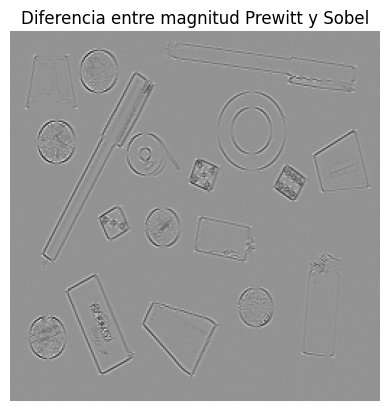

In [23]:
subtraction = cv2.subtract(magnitud_prewitt, magnitud)
plt.imshow(subtraction, cmap='gray')
plt.title("Diferencia entre magnitud Prewitt y Sobel")
plt.axis("off")
plt.show()

## ¿Qué diferencia visual hay entre el operador de Sobel y el de Prewitt?

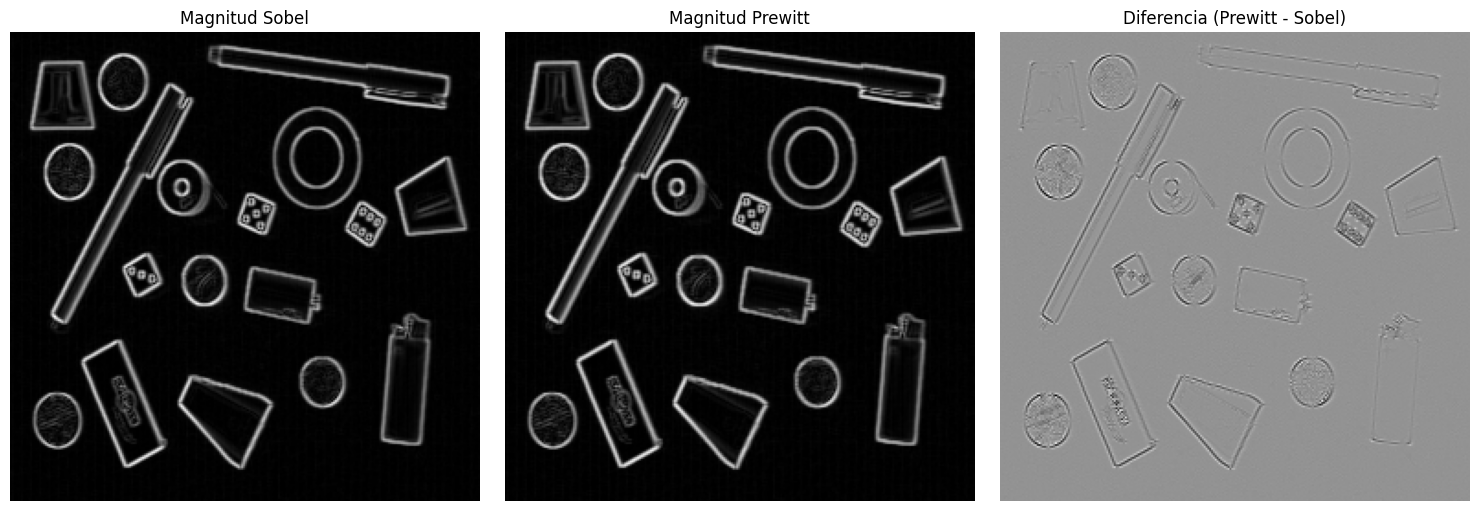

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(magnitud, cmap='gray')
axs[0].set_title('Magnitud Sobel')
axs[0].axis('off')
axs[1].imshow(magnitud_prewitt, cmap='gray')
axs[1].set_title('Magnitud Prewitt')
axs[1].axis('off')
axs[2].imshow(subtraction, cmap='gray')
axs[2].set_title('Diferencia (Prewitt - Sobel)')
axs[2].axis('off')
plt.tight_layout()
plt.show()

La diferencia visual entre ambos operadores es muy sutil. Podemos ver como ambos resaltan los bordes de los objetos de manera similar y que logran mostrar los contornos completos. La imagen *Diferencia (Prewitt - Sobel)* muestra que sí hay una diferencia entre ambos. Esto se debe a que el kernel de Sobel le da mayor peso al centro, mientras Prewitt nos da un filtro más suavizado.

## Para explicar esta diferencia, calcule numéricamente las respuestas del cálculo del gradiente en *x*, en *y* y de la norma del gradiente de cada uno de los dos filtros en los siguientes casos:

[![filtros_punto_15_taller4](./imagenes/filtros_punto_15_taller4.PNG)](./imagenes/filtros_punto_15_taller4.PNG)

Creamos las matrices de los operadores y de las fronteras propuestas en el ejercicio.

In [ ]:

# Máscaras Sobel
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])
sobel_y = np.array([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])

# Máscaras Prewitt
prewitt_x = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])
prewitt_y = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
])

# Frontera horizontal
matriz_frontera_horizontal = np.array([
    [0, 0, 0],
    [0, 0, 0],
    [255, 255, 255]
], dtype=np.int32)

# Frontera vertical
matriz_frontera_vertical = np.array([
    [0, 0, 255],
    [0, 0, 255],
    [0, 0, 255]
], dtype=np.int32)

# Frontera oblicua
matriz_frontera_oblicua = np.array([
    [0, 0, 255],
    [0, 255, 255],
    [255, 255, 255]
], dtype=np.int32)

# Frontera alejada
matriz_mascara_alejada = np.array([
    [0,   0,   0],
    [0,   0,   0],
    [0,   0, 255]
], dtype=np.int32)


In [25]:
def calcula_gradiente(matriz, mascara_x, mascara_y):
    gx = np.sum(matriz * mascara_x)
    gy = np.sum(matriz * mascara_y)
    norma = abs(gx) + abs(gy)
    return gx, gy, norma